## ReadMe
This is HazardPyMatch, a Chemical Inventory and Hazard Analysis Pipeline.

The software prompts the user for Globally Harmonized System (GHS) H-codes.

Choose your H-codes of interest using this resource:
https://pubchem.ncbi.nlm.nih.gov/ghs

Please additionally refer to the ReadMe document included on GitHub for explicit instructions on and screenshots for how to prepare to run and how to successfully execute the software!

https://github.com/emp2163/HazardPyMatch

# Define I/O configuration and file system paths

In [ ]:
import os
import glob
from google.colab import drive
drive.mount('/content/drive')

# Define all person specific locations and file names
# Define source folder
source_folder = '/content/drive/My Drive/your_source_folder/'

# Define location of Chemical Inventory, which is an input list including 'Chemical Names' and 'CAS Numbers' column names
inventory_files = glob.glob(os.path.join(source_folder, '*Chemical_Inventory*.xlsx'))

# Define protocol folder
protocols_folder = os.path.join(source_folder, 'your_protocols_folder')

# = True if you want to print intermediate steps of chemical inventory dataframe for debugging.
# Set at = False as default
print_intermediate_steps = False

# Prompt the user to input relevant GHS codes
print("Enter relevant GHS codes separated by commas (e.g., H200, H201, H360FD):")
relevant_ghs_codes = input().strip().split(',')

# Import packages and load the chemical inventory

In [ ]:
# Import packages and load chemical inventory

!pip install bs4
!pip install pdfplumber
!pip install pubchempy

# Import packages
import numpy as np
import pandas as pd
import requests
import re
import time
from bs4 import BeautifulSoup
import pubchempy as pcp
import tkinter
from tkinter import *
from tkinter import filedialog
import pdfplumber
import requests
import json
import matplotlib.pyplot as plt
from collections import Counter
import networkx as nx
from concurrent.futures import ThreadPoolExecutor, as_completed
import sys


df_inventory = pd.DataFrame()
# Load .xlsx or .csv Chemical Inventory file
try:
    if len(inventory_files) == 0:
        print("No .xlsx files found with 'Chemical_Inventory' in the name. Searching for .csv files...")

        # Search for .csv files
        inventory_files = glob.glob(os.path.join(source_folder, '*Chemical_Inventory*.csv'))

        if len(inventory_files) == 0:
            print("No .csv files found either. Please check the source folder.")
        else:
            # Use the first .csv file that matches the pattern
            csv_path = inventory_files[0]
            print(f"Loading file: {csv_path}")
            # Load the .csv file into a DataFrame
            df_inventory = pd.read_csv(
                csv_path,
                usecols=["Chemical Name", "CAS Number"]  # Adjust columns to match your file
            )
            print("CSV file loaded successfully.")
    else:
        # Use the first .xlsx file that matches the pattern
        excel_path = inventory_files[0]
        print(f"Loading file: {excel_path}")
        # Load the .xlsx file into a DataFrame
        df_inventory = pd.read_excel(
            excel_path,
            engine='openpyxl',
            usecols=["Chemical Name", "CAS Number"]  # Adjust columns to match your file
        )
        print("Excel file loaded successfully.")

    # Display the first few rows of the DataFrame
    print(df_inventory.head())
except ValueError as ve:
    print(f"Error loading file: {ve}")
except FileNotFoundError as fnfe:
    print(f"File not found: {fnfe}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# Backup main inventory
df_inventory_backup_orig = df_inventory.copy()

# Abort if backup is empty (no rows)
if df_inventory_backup_orig.empty:
    print("ERROR: df_inventory is empty after copy. Aborting run.", flush=True)
    sys.exit(1)  # stops the script; replace with `raise RuntimeError(...)` if you prefer an exception


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 93.7 MB/s eta 0:00:00
No .xlsx files found with 'Chemical_Inventory' in the name. Searching for .csv files...
Loading file: /content/drive/My Drive/ZIGI_Research_EMP_shared_folder/pipeline/Sample Chemical_Inventory.csv
CSV file loaded successfully.
                             Chemical Name CAS Number
0                                  Ethanol    64-17-5
1  Ethylenediaminet etraacetic acid (EDTA)    60-00-4
2                                   Phenol   108-95-2
3                                 Triton X  9036-19-5
4                             Formaldehyde    50-00-0


#CAS Number filter





In [ ]:
# Check for and correct multiple CAS Numbers per row.
def expand_multiple_cas_rows(df_inventory, cas_column="CAS Number", name_column="Chemical Name"):
    # Define CAS number regex pattern
    cas_pattern = r'\b\d{2,7}-\d{2}-\d\b'
    expanded_rows = []

    for _, row in df_inventory.iterrows():
        cas_field = str(row[cas_column])
        matches = re.findall(cas_pattern, cas_field)

        if len(matches) <= 1:
            expanded_rows.append(row.to_dict())
        else:
            for cas in matches:
                new_row = row.to_dict()
                new_row[cas_column] = cas.strip()
                expanded_rows.append(new_row)

    return pd.DataFrame(expanded_rows)

# Fetch all CAS Numbers per chemical name
def get_all_cas_from_name_only(chemical_name):
    """Directly fetch CAS Numbers for a chemical name from PubChem."""
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{chemical_name}/xrefs/RegistryID/JSON"
        response = requests.get(url)
        if response.status_code != 200:
            return []

        info_list = response.json().get("InformationList", {}).get("Information", [])
        all_cas = set()
        for entry in info_list:
            for reg_id in entry.get("RegistryID", []):
                if re.match(r'^\d{2,7}-\d{2}-\d$', reg_id):
                    all_cas.add(reg_id)

        return sorted(all_cas)

    except Exception as e:
        print(f"Error retrieving CAS numbers for {chemical_name}: {e}")
        return []

# Fill in missing CAS numbers
def fill_missing_cas(df):
    for i, row in df.iterrows():
        if pd.isna(row["CAS Number"]) or row["CAS Number"] == "":
            cas = get_all_cas_from_name_only(row["Chemical Name"])
            if cas:
                df.at[i, "CAS Number"] = cas
    return df

# Expand input chemical inventories with >1 CAS Number per chemical name to ensure 1 CAS per row
df_inventory = expand_multiple_cas_rows(df_inventory)


print("Populating missing CAS Numbers...")
# Fill in missing CAS Numbers
df_inventory = fill_missing_cas(df_inventory)


print("...Extracting and saving list of chemical names with no CAS Number...")
# Create DataFrame for chemicals without CAS
df_proprietaryRxs_andOther = df_inventory[
    df_inventory["CAS Number"].isna() | (df_inventory["CAS Number"] == "") | (df_inventory["CAS Number"] == 0)
].copy()


# Clean and validate CAS numbers
invalid_chars = set("[],./?!@#$%^&*():;\"'")

rows_to_add = []
for i, val in df_inventory["CAS Number"].items():
    if isinstance(val, list) and val:  # if it's a non-empty list
        # Keep the first CAS in the current row, add the rest as new rows
        df_inventory.at[i, "CAS Number"] = val[0]
        for cas_extra in val[1:]:
            new_row = df_inventory.loc[i].copy()
            new_row["CAS Number"] = cas_extra
            rows_to_add.append(new_row)

if rows_to_add:
    df_inventory = pd.concat([df_inventory, pd.DataFrame(rows_to_add)], ignore_index=True)

for i, val in df_inventory["CAS Number"].items():
    cas = str(val).split(" ")[0].strip() if not pd.isna(val) else ""
    if any(c.isalpha() or c in invalid_chars for c in cas):
        df_inventory.at[i, "CAS Number"] = ""
        continue
    if "-" in cas:
        parts = cas.split("-")
        if len(parts) == 3:
            try:
                parts[2] = str(int(parts[2]))  # strip leading 0s
                df_inventory.at[i, "CAS Number"] = "-".join(parts)
            except ValueError:
                df_inventory.at[i, "CAS Number"] = ""


# Remove rows with no found CAS Number(s) from main inventory
df_inventory = df_inventory[
    ~(df_inventory["CAS Number"].isna() | (df_inventory["CAS Number"] == "") | (df_inventory["CAS Number"] == 0))
]

# Save results
if print_intermediate_steps:
    output_path = os.path.join(source_folder, "df_inventory_withCAS.xlsx")
    df_inventory.to_excel(output_path, index=False)

# Clean duplicates for proprietary/other list
df_proprietaryRxs_andOther["Chemical Name"] = df_proprietaryRxs_andOther["Chemical Name"].str.strip().str.lower()
df_proprietaryRxs_andOther = df_proprietaryRxs_andOther.drop_duplicates(subset="Chemical Name", keep="first")
df_proprietaryRxs_andOther["Chemical Name"] = df_proprietaryRxs_andOther["Chemical Name"].str.title()

# Save proprietary/unknown list
output_path = os.path.join(source_folder, "List_of_Chemical_Names_lacking_CAS_Numbers.xlsx")
df_proprietaryRxs_andOther.to_excel(output_path, index=False)

print("...CAS Number population and cleanup complete.")


Populating missing CAS Numbers...
...Extracting and saving list of chemical names with no CAS Number...
...CAS Number population and cleanup complete.


#CID and GHS H-Code Scraper
The code in the next two code blocks - credit to github user chadr1989:

https://github.com/chadr1989/GHS-codes-from-CAS-numbers/blob/main/GHS_codes_NCBI_scrape.ipynb



In [ ]:
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

# Fetch all IDs for each CAS number
def get_cids_from_cas(cas_number):
    try:
        cas_number = str(cas_number).strip()
        cids = set()

        # Compound database
        compound_url = f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/xref/RN/{cas_number}/cids/JSON'
        r1 = requests.get(compound_url)

        if r1.status_code == 200:
          response_json = r1.json()

          # Check if response contains a fault (e.g., "PUGREST.NotFound")
          if "Fault" in response_json and "PUGREST.NotFound" in response_json["Fault"].get("Code", ""):
              print(f"No CIDs found for CAS {cas_number}")
              return cids  # Return empty set

          # Otherwise, try to extract CIDs
          compound_cids = response_json.get("IdentifierList", {}).get("CID", [])
          if compound_cids:
              cids.update(compound_cids)
              print(f"  Compound CIDs for CAS {cas_number}: {compound_cids}")
          else:
              print(f"No CIDs in IdentifierList for CAS {cas_number}")
        else:
          print(f"Request failed for CAS {cas_number} with status code {r1.status_code}")

        # Substance database
        substance_url = f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/substance/xref/RN/{cas_number}/cids/JSON'
        r2 = requests.get(substance_url)
        substance_cids = []
        if r2.status_code == 200:
            substance_data = r2.json()
            for info in substance_data.get('InformationList', {}).get('Information', []):
                if 'CID' in info:
                    substance_cids.extend(info['CID'])
            cids.update(substance_cids)
        print(f"  Substance CIDs for CAS {cas_number}: {substance_cids}")
        print(f"  Unique total CIDs for CAS {cas_number}: {len(cids)}")

        return list(cids)
    except Exception as e:
        print(f" Error retrieving CIDs for CAS {cas_number}: {e}")
        return []


# Create a new row when >1 IDs per CAS Number
def process_cas_to_rows(cas_number, chemical_name):
    rows = []
    cas_number_str = str(cas_number).strip()
    cids = get_cids_from_cas(cas_number_str)

    for cid in cids:
      time.sleep(1.1)
      result = requests.get(f'https://pubchem.ncbi.nlm.nih.gov/rest/pug_view/data/compound/{int(cid)}/JSON/?response_type=display&heading=GHS%20Classification','lxml')
      soup = BeautifulSoup(result.text,'lxml').text
      joined_ghs = 'No GHS h-codes found for this PubChemID' #GHS h-codes are not often provided for entries in PubChem's substance database

      if len(soup) > 90:
          pattern_hits = [m.start() for m in re.finditer(r'"H\d\d\d', soup)]
          ghs_codes_set = set()
          for i in range(0,len(pattern_hits)):
              phrase_start = pattern_hits[i]
              phrase_end = soup[phrase_start+1:].find('"')
              ghs_codes_set.add(soup[phrase_start+1:phrase_start+5])
          ghs_codes_list = list()
          for c in ghs_codes_set:
              ghs_start = soup.find(c)
              ghs_end = soup[soup.find(c)+1:].find('"')+1
              ghs_codes_list.append(soup[ghs_start:ghs_start+ghs_end])
          joined_ghs = ' --- '.join(ghs_codes_list)

      else:
          print(f"No GHS information found for PubChem ID {cid}")
          pass

      rows.append({
          'Chemical Name': chemical_name,
          'CAS Number': cas_number_str,
          'PubChem ID': cid,
          'H Codes': joined_ghs
          })
    return rows


# Execute PubChemID pull and GHS pull with multiple workers
def run_ghs_longform_pipeline(df_inventory, max_workers=5):
    all_rows = []

    # Clean inputs
    df_inventory["Chemical Name"] = df_inventory["Chemical Name"].astype(str).str.strip()
    df_inventory["CAS Number"] = df_inventory["CAS Number"].astype(str).str.strip()

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(process_cas_to_rows, row["CAS Number"], row["Chemical Name"]): (row["CAS Number"], row["Chemical Name"])
            for _, row in df_inventory.iterrows()
        }
        for future in as_completed(futures):
            try:
                all_rows.extend(future.result())
            except Exception as e:
                cas, name = futures[future]
                print(f"Error processing {cas} ({name}): {e}")

    return pd.DataFrame(all_rows)


# Execute using multiple workers:
df_long = run_ghs_longform_pipeline(df_inventory)
df_inventory = df_long.copy()


  Compound CIDs for CAS 9036-19-5: [5590, 24775, 75622, 94543, 560774, 628327, 5460632, 14123494, 22345682, 135407139, 162103267]
  Compound CIDs for CAS 50-00-0: [712]
  Compound CIDs for CAS 64-17-5: [702]
  Compound CIDs for CAS 60-00-4: [3077, 6049, 6144, 5232305, 18185437, 22141944]
  Compound CIDs for CAS 108-95-2: [996, 7966, 78386, 220721, 20488062]
  Substance CIDs for CAS 50-00-0: [712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 712, 

In [ ]:
# Fail safe execution code block for fetching H-Codes

def is_blank(x):
    # Treat NaN or empty/whitespace as blank
    return pd.isna(x) or str(x).strip() == ""

def fetch_ghs_for_cid(cid):

    try:
        cid_int = int(str(cid).strip())
    except Exception:
        return None  # If can't use this CID

    time.sleep(1.1)  # Included to decrease chance of throttling errors
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug_view/data/compound/{cid_int}/JSON/?response_type=display&heading=GHS%20Classification"
    r = requests.get(url)
    if r.status_code != 200:
        return None

    soup_text = BeautifulSoup(r.text, "lxml").text
    joined_ghs = 'No GHS h-codes found for this PubChemID'

    if len(soup_text) > 90:
        pattern_hits = [m.start() for m in re.finditer(r'"H\d\d\d', soup_text)]
        ghs_codes_set = set()
        for i in range(len(pattern_hits)):
            phrase_start = pattern_hits[i]
            phrase_end = soup_text[phrase_start+1:].find('"')
            ghs_codes_set.add(soup_text[phrase_start+1:phrase_start+5])

        ghs_codes_list = []
        for c in ghs_codes_set:
            ghs_start = soup_text.find(c)
            ghs_end = soup_text[soup_text.find(c)+1:].find('"') + 1
            ghs_codes_list.append(soup_text[ghs_start:ghs_start+ghs_end])

        if ghs_codes_list:
            joined_ghs = ' --- '.join(ghs_codes_list)

    return joined_ghs

# For rows where H-code blank, use PubChem ID to fetch H-codes
def fill_missing_hcodes(df_inventory):

    # Ensure column exists
    if "H Codes" not in df_inventory.columns:
        df_inventory["H Codes"] = np.nan

    mask = df_inventory["H Codes"].apply(is_blank)
    rows_to_update = df_inventory[mask].index

    for idx in rows_to_update:
        cid = df_inventory.at[idx, "PubChem ID"]
        if pd.isna(cid) or str(cid).strip() == "":
            continue  # no CID to use

        joined_ghs = fetch_ghs_for_cid(cid)
        # Only write if we actually got something (including the default message)
        if joined_ghs is not None:
            df_inventory.at[idx, "H Codes"] = joined_ghs

    return df_inventory


df_inventory = fill_missing_hcodes(df_inventory)
print(df_inventory.head())


      Chemical Name  CAS Number  PubChem ID  \
0      Formaldehyde     50-00-0         712   
1           Ethanol     64-17-5         702   
2          Methanol     67-56-1         887   
3  Paraformaldehyde  30525-89-4         712   
4  Paraformaldehyde  30525-89-4       79015   

                                             H Codes  
0  H319: Causes serious eye irritation [Warning S...  
1  H319 (37.7%): Causes serious eye irritation [W...  
2  H319: Causes serious eye irritation [Warning S...  
3  H319: Causes serious eye irritation [Warning S...  
4            No GHS h-codes found for this PubChemID  


#GHS H-Code filter

In [ ]:
# Clean and filter the H-Codes column

# Strip common zero-width chars and normalize some odd spaces/dashes minimally.
ZERO_WIDTH_PATTERN = re.compile(r'[\u200B-\u200D\uFEFF]')

def _clean_text(s: str) -> str:
    s = str(s)
    s = ZERO_WIDTH_PATTERN.sub('', s)
    s = s.replace('\u00A0', ' ')
    s = s.replace('\u202F', ' ')
    return s

df_inventory['H Codes'] = df_inventory['H Codes'].fillna('').map(_clean_text)

# Accepts forms like: H341, H341:, H-341, H 341, H 341 (NBSP), H–341 (en dash), H360Df, etc.
hcode_regex = re.compile(
    r'(?<![A-Za-z0-9])'
    r'H(?:[-\u2010-\u2015\u2212\u2043]|\s|\u00A0|\u202F)?'
    r'(?P<num>\d{3})(?P<sfx>[A-Za-z]{0,3})?'
    r'(?![A-Za-z0-9])',
    re.IGNORECASE
)

# Extract H-codes
def extract_hcodes(text: str):
    matches = [m.group(0).upper() for m in hcode_regex.finditer(text)]
    canonical = sorted({'H' + re.search(r'\d{3}', m).group(0) for m in matches})
    return canonical

df_inventory['H_codes_found'] = df_inventory['H Codes'].map(extract_hcodes)

# Canonicalize your relevant list and flag rows
canonical_relevant = {'H' + re.search(r'\d{3}', c.upper()).group(0) for c in relevant_ghs_codes}

df_inventory['has_relevant'] = df_inventory['H_codes_found'].apply(
    lambda lst: any(code in canonical_relevant for code in lst)
)

# Optional: which relevant codes matched (helps debugging)
df_inventory['matched_relevant'] = df_inventory['H_codes_found'].apply(
    lambda lst: sorted(set(lst) & canonical_relevant)
)

# Split into relevant vs other dataframes
relevant_ghs_df = df_inventory[df_inventory['has_relevant']].copy()
other_ghs_df    = df_inventory[~df_inventory['has_relevant']].copy()

# Exit if no relevant H-codes were found
if relevant_ghs_df.empty:
    print("\nNo relevant GHS H codes were found in the inventory. Halting downstream steps.")
    # Stop executing any subsequent code
    raise SystemExit(0)

# Preview lists
print("\nRelevant GHS H Codes DataFrame:")
print(relevant_ghs_df.head())
print("\nIrrelevant GHS H Codes DataFrame:")
print(other_ghs_df.head())



Relevant GHS H Codes DataFrame:
      Chemical Name  CAS Number  PubChem ID  \
0      Formaldehyde     50-00-0         712   
1           Ethanol     64-17-5         702   
2          Methanol     67-56-1         887   
3  Paraformaldehyde  30525-89-4         712   
6            Phenol    108-95-2         996   

                                             H Codes  \
0  H319: Causes serious eye irritation [Warning S...   
1  H319 (37.7%): Causes serious eye irritation [W...   
2  H319: Causes serious eye irritation [Warning S...   
3  H319: Causes serious eye irritation [Warning S...   
6  H411 (13.6%): Toxic to aquatic life with long ...   

                                       H_codes_found  has_relevant  \
0  [H220, H227, H280, H301, H302, H311, H314, H31...          True   
1  [H225, H315, H319, H320, H335, H336, H340, H35...          True   
2  [H225, H301, H302, H303, H311, H319, H331, H33...          True   
3  [H220, H227, H280, H301, H302, H311, H314, H31...          True 

In [ ]:
# Save dataframe with all chemicals in inventory with relevant GHS codes to an Excel file
output_filename = None
output_path = None
output_filename = 'Chemical_Inventory_containing_only_user_chosen_GHS_Hcodes.xlsx'
output_path = os.path.join(source_folder, output_filename)
relevant_ghs_df.to_excel(output_path, index=False)

if print_intermediate_steps:
  output_filename = None
  output_path = None
  output_filename = 'Chemical_Inventory_with_irrelevant_GHS_Hcodes.xlsx'
  output_path = os.path.join(source_folder, output_filename)
  other_ghs_df.to_excel(output_path, index=False)

#In-list synonyms compiler

In [ ]:
# Replace df_inventory (all GHS codes) with relevant_ghs_df
df_inventory = relevant_ghs_df

# Convert 'PubChem ID' column to string
df_inventory['PubChem ID'] = df_inventory['PubChem ID'].astype(str)

# Sort the dataframe based on 'PubChem ID' in ascending order
df_sorted = df_inventory.sort_values(by='PubChem ID')

# Create a new dataframe to store unique PubChem IDs
unique_pubchem_ids = pd.DataFrame(columns=df_inventory.columns)

# List to collect data for the new chemical name columns
new_columns_data = []

# Loop through sorted dataframe to extract first entry for each unique PubChem ID
for pubchem_id, group in df_sorted.groupby('PubChem ID'):
    # Get the first row for the unique PubChem ID
    first_entry = group.iloc[0].to_frame().T

    # Append the first entry to unique_pubchem_ids
    unique_pubchem_ids = pd.concat([unique_pubchem_ids, first_entry], ignore_index=True)

    # Create a temporary list of Chemical Names matching the unique PubChem ID
    chemical_names = group['Chemical Name'].tolist()

    # Remove duplicates from the chemical names list
    unique_chemical_names = list(dict.fromkeys(chemical_names))

    # Add the unique chemical names as a list (will be used to create new columns)
    new_columns_data.append(unique_chemical_names)

# Ensure new_columns_data is not empty before applying max()
if not new_columns_data or all(len(names) == 0 for names in new_columns_data):
    print("You have no chemicals in this inventory with relevant GHS codes!")
else:
    # Create a new dataframe for the chemical names, handling varying numbers of chemical names per PubChem ID
    max_names = max([len(names) for names in new_columns_data])
    chemical_names_df = pd.DataFrame([
        names + [None] * (max_names - len(names)) for names in new_columns_data
    ], columns=[f'inventory synonym {i+1}' for i in range(max_names)])

    # Concatenate the chemical names dataframe with unique_pubchem_ids
    unique_pubchem_ids = pd.concat([unique_pubchem_ids.reset_index(drop=True), chemical_names_df.reset_index(drop=True)], axis=1)


In [ ]:
# Save the df_inventory with unique GHS codes DataFrame to an Excel file
if print_intermediate_steps:
  output_filename = None
  output_path = None
  output_filename = 'df_inventory_relevantGHScodes_uniquecodes_inlistsyns.xlsx'
  output_path = os.path.join(source_folder, output_filename)
  unique_pubchem_ids.to_excel(output_path, index=False)
  output_filename = None
  output_path = None

#PubChem synonym requests


In [ ]:
# Replace df_inventory with unique_pubchem_ids
df_inventory = unique_pubchem_ids

# Define master list
master_list = df_inventory['CAS Number'].astype(str).str.strip().tolist()

# Search for synonyms using CAS Number
def search_hazard_synonyms_and_save_to_excel(master_list, input_df):

    results = []

    # Ensure the CAS Numbers  are strings with no spaces
    master_list = [str(cas_number).strip() for cas_number in master_list]

    for cas_number in master_list:
        print(f'Processing CAS Number: {cas_number}')

        try:
            # URL for retrieving compound synonyms based on CAS Number
            url = f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{cas_number}/synonyms/TXT'

            # HTTP GET request to the PubChem API
            response = requests.get(url)

            # Check if the request was successful
            if response.status_code == 200:
                synonyms_text = response.text.strip().split("\n")
                # Append the CAS number and all synonyms to the results list
                results.append([cas_number] + synonyms_text)
            elif response.status_code == 404:
                substance_url = f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/substance/xref/RN/{cas_number}/cids/JSON'
                substance_response = requests.get(substance_url)

                if substance_response.status_code == 200:
                    synonyms_text = substance_response.text.strip().split("\n")
                    results.append([cas_number] + synonyms_text)
                else:
                    print(f'Substance not found or another error: {substance_response.status_code}')
                    results.append([cas_number, f'Substance Error: {substance_response.status_code}'])

        except Exception as e:
            print(f'Error processing CAS Number: {cas_number}')
            print(f'Error message: {str(e)}')
            results.append([cas_number, f'Error: {str(e)}'])

    # Convert the results to a DataFrame (expand columns dynamically based on the max number of synonyms)
    df_synonyms = pd.DataFrame(results)

    # Assign column names dynamically: first column as 'CAS Number' and rest as 'Synonym 1', 'Synonym 2', etc.
    max_synonyms = df_synonyms.shape[1] - 1  # The first column is 'CAS Number', the rest are synonyms
    df_synonyms.columns = ['CAS Number'] + [f'Synonym {i}' for i in range(1, max_synonyms + 1)]

    # Merge the synonyms DataFrame back with the original DataFrame
    output_df = pd.merge(input_df, df_synonyms, on="CAS Number", how="left")

    # Return the DataFrame for further processing or saving
    return output_df

# Save the output DataFrame to an Excel file for debugging
if print_intermediate_steps:
  output_path = None
  output_filename = None
  output_filename = 'df_inventory_relevantGHScodes_uniquecodes_inlistsyns_ncbisyns.xlsx'
  output_path = os.path.join(source_folder, output_filename)
  output_df.to_excel(output_path, index=False)
  print(f"Excel file saved to: {output_path}")


Processing CAS Number: 72-57-1
Processing CAS Number: 1330-43-4
Processing CAS Number: 13446-34-9
Processing CAS Number: 17372-87-1
Processing CAS Number: 17372-87-1
Processing CAS Number: 6104-58-1
Processing CAS Number: 108-88-3
Processing CAS Number: 592-85-8
Processing CAS Number: 65-31-6
Processing CAS Number: 114-49-8
Processing CAS Number: 6156-78-1
Processing CAS Number: 920-66-1
Processing CAS Number: 72-57-1
Processing CAS Number: 72-57-1
Processing CAS Number: 118-00-3
Processing CAS Number: 72-57-1
Processing CAS Number: 72-57-1
Processing CAS Number: 7791-13-1
Processing CAS Number: 868272-85-9
Processing CAS Number: 7791-20-0
Processing CAS Number: 10034-99-8
Processing CAS Number: 5711-19-3
Processing CAS Number: 2530-83-8
Processing CAS Number: 25322-68-3
Processing CAS Number: 72-57-1
Processing CAS Number: 60-35-5
Processing CAS Number: 67-64-1
Processing CAS Number: 1405-10-3
Processing CAS Number: 114-49-8
Processing CAS Number: 1336-21-6
Processing CAS Number: 114-

In [ ]:
print('Removing duplicate synonyms')

# Work on output_df directly
df_inventory = output_df.copy()

# Columns E (index 4) to last
syn_cols = df_inventory.columns[4:]

def _unique_order(seq):
    seen = set()
    out = []
    for x in seq:
        k = x  # case-sensitive; switch to x.lower() if you want case-insensitive
        if k not in seen:
            seen.add(k)
            out.append(x)
    return out

def dedup_cell(val):
    # Leave true missing values as-is
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return np.nan

    # If it's already a list/array/tuple, treat as a list of tokens
    if isinstance(val, (list, tuple, np.ndarray)):
        tokens = [str(t).strip() for t in list(np.ravel(val))]
    else:
        # Otherwise split on semicolons
        s = str(val)
        tokens = [t.strip() for t in s.split(';')]

    # Drop empties and 'nan' strings
    tokens = [t for t in tokens if t and t.lower() != 'nan']

    # Deduplicate preserving order
    tokens = _unique_order(tokens)

    # Re-join as semicolon-separated string
    return ';'.join(tokens) if tokens else np.nan

# Apply to all synonym columns
df_inventory.loc[:, syn_cols] = df_inventory.loc[:, syn_cols].applymap(dedup_cell)

dims = df_inventory.shape
print("DataFrame shape after dedup:", dims)

# Save back to output_df and export
output_df = df_inventory

# Save the output DataFrame to an Excel file for debugging
if print_intermediate_steps:
  output_path = None
  output_filename = None
  output_filename = 'df_inventory_relevantGHScodes_uniquecodes_inlistsyns_ncbisyns.xlsx'
  output_path = os.path.join(source_folder, output_filename)
  output_df.to_excel(output_path, index=False)
  print(f"Excel file saved to: {output_path}")


Removing duplicate synonyms


/tmp/ipython-input-3832836950.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_inventory.loc[:, syn_cols] = df_inventory.loc[:, syn_cols].applymap(dedup_cell)


DataFrame shape after dedup: (277, 9294)
Excel file saved to: /content/drive/My Drive/ZIGI_Research_EMP_shared_folder/pipeline/df_inventory_relevantGHScodes_uniquecodes_inlistsyns_ncbisyns.xlsx


# Pdfplumber protocol search, match and record

In [ ]:
# Populate protocols with the names of PDF files
protocols = []
for filename in os.listdir(protocols_folder):
    if filename.endswith('.pdf'):
        protocols.append(filename[:-4])
print(protocols)

['Enzyme-Linked Immunosorbent Assay (ELISA)_Thermo Scientific', 'Western Blot (WB)_BioRad', 'Polymerase Chain Reaction (PCR)_The Jackson Laboratory', 'Open Field Test_Stanford University', 'Whole-cell Patch-clamp_Axol Bio', 'Nissl Staining_Cold Spring Harbor Protocols', 'In Situ Hybridization (ISH)_Abcam', 'Immunoprecipitation (IP)_Abcam', 'Imaging protocol handbook_ThermoFisher', 'Chromogenic In Situ Hybridization (CISH)_Springer Protocols']


In [ ]:
# This is the protocol pdf matching code. Toward completeness, we include all found Pubchem IDs and synonyms
# This results in occasional false positives particuarly when PubChem synonym list contains commonly used words like 'Clean' or 'not have'
# The code outputs a hazards detail list so you can view the synonym found in the protocol pdf file and ignore the false positives.

# Initialize lists
master_list = []
hazards = []

import logging

# Silence pdfminer warnings
for name in ("pdfminer", "pdfminer.pdfinterp", "pdfminer.pdfdevice", "pdfminer.psparser", "pdfminer.layout"):
    logging.getLogger(name).setLevel(logging.ERROR)


# Populate the master list with CAS Numbers, synonyms, PubChem ID, and GHS Codes
for index, row in df_inventory.iterrows():
    name = row['Chemical Name']
    cas_number = row['CAS Number']
    pubchem_id = row['PubChem ID']
    ghs_codes = row['matched_relevant']
    synonyms = row[7:]  # Get all synonyms starting from the 8th column

    for synonym in synonyms:
        if pd.notna(synonym):  # Ensure synonym is not NaN
            # Append with CAS number, synonym, PubChem ID, and GHS Codes
            master_list.append((name, cas_number, synonym.strip(), pubchem_id, ghs_codes))

# Convert master_list to a DataFrame
master_list_df = pd.DataFrame(master_list, columns=['Chemical Name', 'CAS Number', 'Synonym', 'PubChem ID', 'H Codes'])
master_list_df.columns = master_list_df.columns.str.replace(' ', '_')

# Display the resulting DataFrame
print(master_list_df)
master_list_df.shape



        Chemical_Name CAS_Number  \
0         Trypan blue    72-57-1   
1         Trypan blue    72-57-1   
2         Trypan blue    72-57-1   
3         Trypan blue    72-57-1   
4         Trypan blue    72-57-1   
...               ...        ...   
89166  Phenol, liquid   108-95-2   
89167  Phenol, liquid   108-95-2   
89168  Phenol, liquid   108-95-2   
89169  Phenol, liquid   108-95-2   
89170  Phenol, liquid   108-95-2   

                                                 Synonym PubChem_ID  \
0                                            Trypan blue  101417452   
1                                    C.I. Direct Blue 14  101417452   
2                                          DTXSID4026268  101417452   
3                                           DTXCID006268  101417452   
4                                        RefChem:1080556  101417452   
...                                                  ...        ...   
89166  Phenol water-saturated, stabilised and with se...        996   

In [ ]:
# This is the code block where the PDF matching occurs
# Code execution will take at least 2 minutes to run - with a high number of protocols and extensive lists it can take up to 3 hours to run.

# Initialize lists
hazards = []
matched_details = []

for filename in os.listdir(protocols_folder):
    print(f"Processing protocol: {filename}")
    if filename.endswith('.pdf') and filename != "Hazards_in_Protocols.txt":
        extracted_text = ''
        try:
            with pdfplumber.open(os.path.join(protocols_folder, filename)) as pdf:
                for page_num, page in enumerate(pdf.pages):
                    page_text = page.extract_text() or ''
                    extracted_text += page_text
        except Exception as e:
            print(f"Error processing protocol {filename}: {e}")
            continue

        # Initialize per-file accumulators
        matched_cas_numbers = []
        matched_pubchem_ids = []
        matched_ghs_codes = []
        matched_details_local = []

        # Scan all synonyms against the extracted text
        for row in master_list_df.itertuples(index=False):
            cas_number = getattr(row, 'CAS_Number', None)
            synonym   = getattr(row, 'Synonym', None)
            pubchem_id = getattr(row, 'PubChem_ID', None)
            ghs_codes  = getattr(row, 'H_Codes', None)

            # whole-word, case-sensitive match
            pattern = fr'\b{re.escape(str(synonym))}\b'
            if re.search(pattern, extracted_text):
                matched_cas_numbers.append(str(cas_number))
                matched_pubchem_ids.append(str(pubchem_id))
                matched_ghs_codes.append(str(ghs_codes))
                matched_details_local.append({
                    'Protocol': filename,
                    'Specific word pulled from pdf': synonym,
                    'Matched CAS Number': cas_number,
                    'Matched PubChem ID': pubchem_id,
                    'Matched GHS H Codes': ghs_codes
                })

        # De-duplicate by CAS number within protocol while preserving order
        seen = set()
        keep_idx = []
        for i, cas in enumerate(matched_cas_numbers):
            if cas not in seen:
                seen.add(cas)
                keep_idx.append(i)

        matched_cas_numbers  = [matched_cas_numbers[i]  for i in keep_idx]
        matched_pubchem_ids  = [matched_pubchem_ids[i]  for i in keep_idx]
        matched_ghs_codes    = [matched_ghs_codes[i]    for i in keep_idx]
        matched_details_keep = [matched_details_local[i] for i in keep_idx]

        # Build hazards row
        list_name = filename.replace('.pdf', '')
        parts = list_name.split('_', 1)
        protocol = parts[0]
        source = parts[1] if len(parts) > 1 else ""

        if not matched_cas_numbers:
            matched_hazards_str = "N/A"
            print(f"No matches found for {filename}")
        else:
            matched_hazards_str = ', '.join(matched_cas_numbers)
            print(f"Matched CAS numbers for {filename}: {matched_hazards_str}")

        hazards.append([protocol, source, matched_hazards_str])
        print(f"Added to hazards list: {protocol}, {source}, {matched_hazards_str}")

        # Extend global details with this protocol's unique hits
        matched_details.extend(matched_details_keep)

# Build DataFrame
df_hazards = pd.DataFrame(hazards, columns=['Protocol', 'Source', 'Hazards'])

# Ensure column names match exactly what you want to see
df_matched_details = pd.DataFrame(matched_details)
# Reorder columns (in case dict insertion order varies)
desired_cols = ['Protocol', 'Specific word pulled from pdf',
                'Matched CAS Number', 'Matched PubChem ID', 'Matched GHS H Codes']
df_matched_details = df_matched_details.reindex(columns=desired_cols)


Processing protocol: Enzyme-Linked Immunosorbent Assay (ELISA)_Thermo Scientific.pdf
Matched CAS numbers for Enzyme-Linked Immunosorbent Assay (ELISA)_Thermo Scientific.pdf: 67-63-0, 64-17-5, 7722-84-1
Added to hazards list: Enzyme-Linked Immunosorbent Assay (ELISA), Thermo Scientific, 67-63-0, 64-17-5, 7722-84-1
Processing protocol: Western Blot (WB)_BioRad.pdf
Matched CAS numbers for Western Blot (WB)_BioRad.pdf: 9036-19-5
Added to hazards list: Western Blot (WB), BioRad, 9036-19-5
Processing protocol: Polymerase Chain Reaction (PCR)_The Jackson Laboratory.pdf
No matches found for Polymerase Chain Reaction (PCR)_The Jackson Laboratory.pdf
Added to hazards list: Polymerase Chain Reaction (PCR), The Jackson Laboratory, N/A
Processing protocol: Open Field Test_Stanford University.pdf
No matches found for Open Field Test_Stanford University.pdf
Added to hazards list: Open Field Test, Stanford University, N/A
Processing protocol: Whole-cell Patch-clamp_Axol Bio.pdf
No matches found for Wh

In [ ]:
# Save the df_inventory list with unique GHS codes DataFrame to an Excel file
output_filename = None
output_path = None
output_filename = 'Hazards_in_Protocols.xlsx'
output_path = os.path.join(source_folder, output_filename)
df_hazards.to_excel(output_path, index=False)
output_filename = None
output_path = None

# Save the df_inventory list including specific words found to an Excel file
output_filename = None
output_path = None
output_filename = 'Protocol_Matched_Hazard_Details.xlsx'
output_path = os.path.join(source_folder, output_filename)
df_matched_details.to_excel(output_path, index=False)
output_filename = None
output_path = None

# Create and save data visualizations

Top 10 protocols with highest number of hazards:
                                    Protocol  Hazard Count
9   Chromogenic In Situ Hybridization (CISH)             9
8                  Imaging protocol handbook             9
6                In Situ Hybridization (ISH)             3
0  Enzyme-Linked Immunosorbent Assay (ELISA)             3
7                   Immunoprecipitation (IP)             2
1                          Western Blot (WB)             1
5                             Nissl Staining             1
4                     Whole-cell Patch-clamp             0
2            Polymerase Chain Reaction (PCR)             0
3                            Open Field Test             0


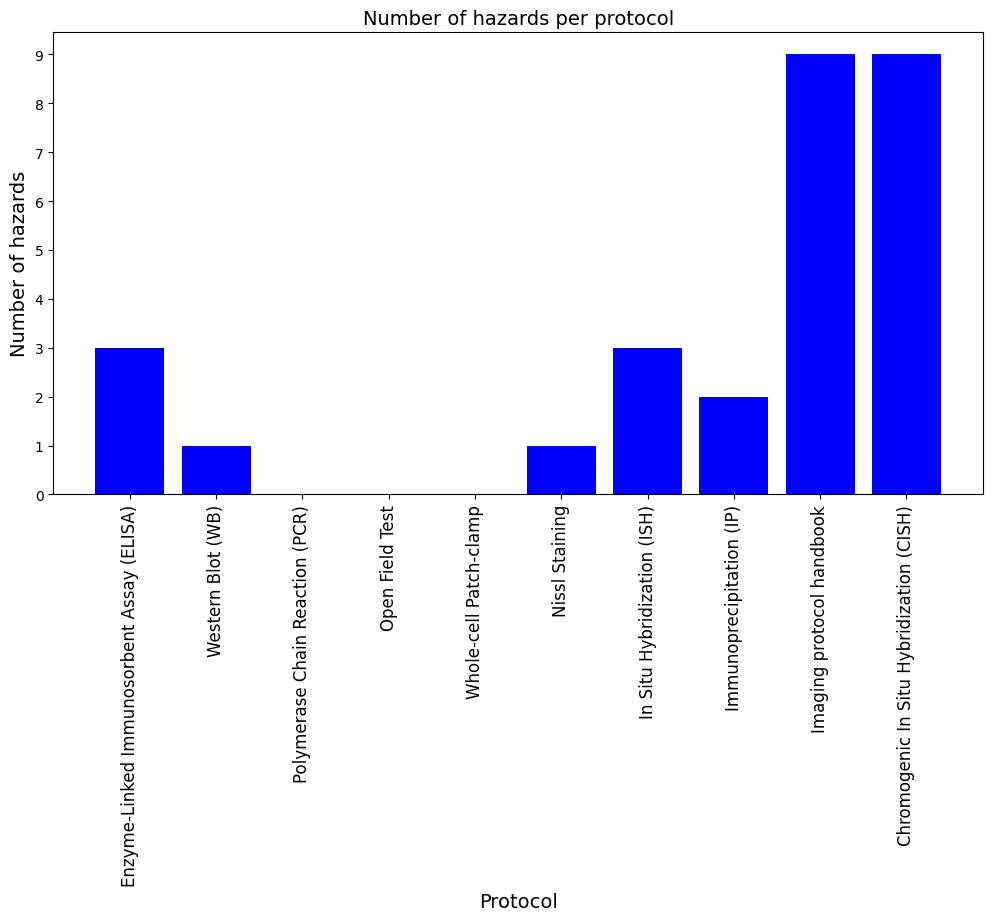

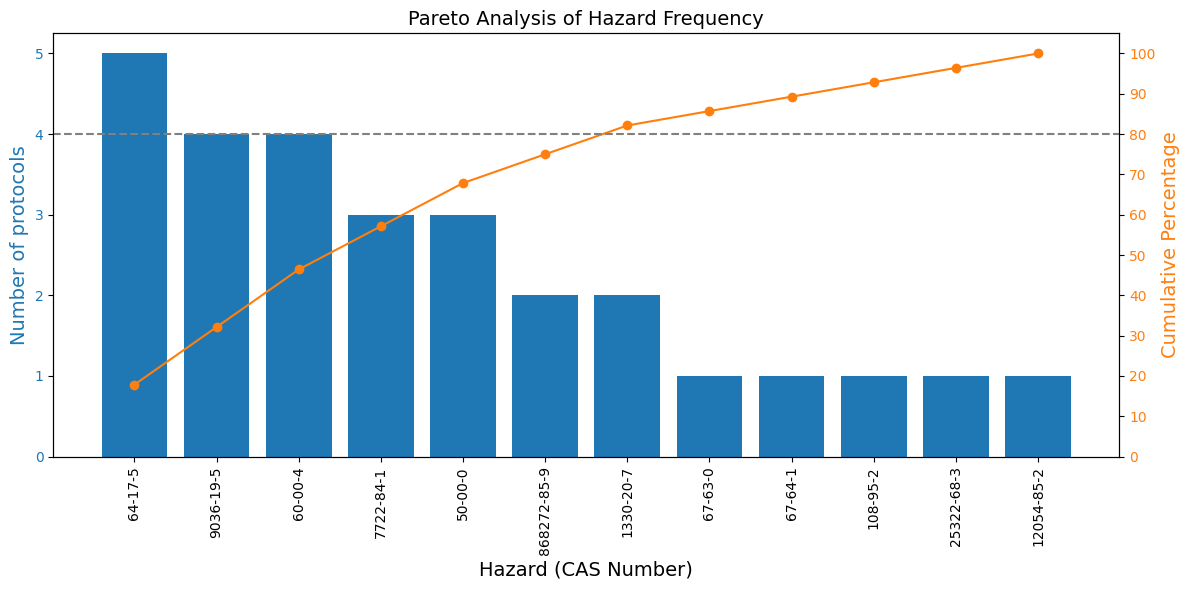

Hazards over 80% Pareto Threshold:
['64-17-5', '9036-19-5', '60-00-4', '7722-84-1', '50-00-0', '868272-85-9']
All hazards (ordered):
['64-17-5', '9036-19-5', '60-00-4', '7722-84-1', '50-00-0', '868272-85-9', '1330-20-7', '67-63-0', '67-64-1', '108-95-2', '25322-68-3', '12054-85-2']


In [ ]:
from matplotlib.ticker import MaxNLocator, MultipleLocator

df = df_hazards.copy()

# Parse hazards per row and exclude N/A and NA
def parse_hazards(cell):
    if pd.isna(cell):
        return []
    tokens = re.split(r'[;,]\s*', str(cell))  # split by comma or semicolon
    tokens = [t.strip() for t in tokens if t.strip()]
    tokens = [t for t in tokens if t.upper() not in {"N/A", "NA"}]
    return tokens

df["Hazard Tokens"] = df["Hazards"].apply(parse_hazards)
df["Hazard Count"]  = df["Hazard Tokens"].map(len)

# Figure size & fonts
fig_size = (12, 6)  # 100%
font = {'family': 'DejaVu Sans', 'size': 14}

# Top 10 protocols by hazard count
top_protocols = df.nlargest(10, "Hazard Count")[["Protocol", "Hazard Count"]]
print("Top 10 protocols with highest number of hazards:")
print(top_protocols)

# Bar chart: Hazards per Protocol
fig, ax = plt.subplots(figsize=fig_size)
ax.bar(df["Protocol"], df["Hazard Count"], color="blue")
ax.set_ylabel("Number of hazards", fontdict=font)
ax.set_title("Number of hazards per protocol", fontdict=font)

# Integer-only ticks on y-axis
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# X labels: vertical + larger font
n_protocols = df["Protocol"].nunique(dropna=True)
if n_protocols > 20:
    # keep your hide rule if too many
    ax.tick_params(axis='x', which='both', labelbottom=False)
    ax.set_xlabel(f"Protocol (labels hidden, {n_protocols} total)", fontdict=font)
else:
    ax.set_xlabel("Protocol", fontdict=font)
    positions = range(len(df["Protocol"]))
    ax.set_xticks(positions)
    ax.set_xticklabels(df["Protocol"], rotation=90, ha="center", fontsize=12)

# Save bar chart to source folder
bar_chart_path = os.path.join(source_folder, "Hazards_Per_Protocol_Bar_Chart.png")
fig.savefig(bar_chart_path, bbox_inches="tight")
plt.show()

# Pareto chart over hazards
hazard_series = df["Hazard Tokens"].explode().dropna()

if hazard_series.empty:
    print("No hazards to plot for Pareto analysis after excluding 'N/A'/'NA'.")
else:
    # Build frequency table without Counter
    cas_df = hazard_series.value_counts().rename_axis("CAS Number").reset_index(name="Frequency")
    cas_df = cas_df.sort_values(by="Frequency", ascending=False, ignore_index=True)

    # Calculate cumulative percentage
    total = cas_df["Frequency"].sum()
    cas_df["Cumulative Frequency"] = cas_df["Frequency"].cumsum()
    cas_df["Cumulative Percentage"] = (cas_df["Cumulative Frequency"] / total) * 100

    # Pareto threshold
    threshold = 80
    pareto_cutoff = cas_df[cas_df["Cumulative Percentage"] <= threshold]

    # Plot Pareto
    fig, ax1 = plt.subplots(figsize=fig_size)

    # Bars for frequency
    ax1.bar(cas_df["CAS Number"], cas_df["Frequency"], color="C0")
    ax1.set_xlabel("Hazard (CAS Number)", fontdict=font)
    ax1.set_ylabel("Number of protocols", fontdict=font, color="C0")
    ax1.tick_params(axis="y", labelcolor="C0")
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Force x axis labels to display vertically
    x_pos = range(len(cas_df["CAS Number"]))
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(cas_df["CAS Number"], rotation=90, ha="center", fontsize=10)

    # Draw cumulative % line
    ax2 = ax1.twinx()
    ax2.plot(x_pos, cas_df["Cumulative Percentage"], color="C1", marker="o", linestyle="-")
    ax2.axhline(y=threshold, color="gray", linestyle="--")
    ax2.set_ylabel("Cumulative Percentage", fontdict=font, color="C1")
    ax2.tick_params(axis="y", labelcolor="C1")
    ax2.set_ylim(0, 105)
    ax2.yaxis.set_major_locator(MultipleLocator(10))

    plt.title("Pareto Analysis of Hazard Frequency", fontdict=font)
    plt.tight_layout()
    plt.show()

    print("Hazards over 80% Pareto Threshold:")
    print(pareto_cutoff["CAS Number"].tolist())
    print("All hazards (ordered):")
    print(cas_df["CAS Number"].tolist())

    pareto_chart_path = os.path.join(source_folder, "CAS_Number_Pareto_Analysis.png")
    fig.savefig(pareto_chart_path, bbox_inches="tight")
    plt.show()
